In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse
import os 
from scipy import stats


In [2]:
df = pd.read_csv('Wine.csv')

df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Customer_Segment      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


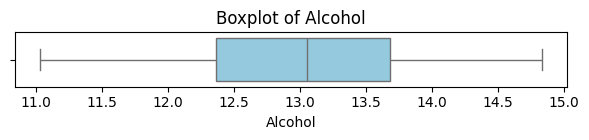

Column: Alcohol
IQR Method - Number of outliers: 0
Z-Score Method - Number of outliers: 0


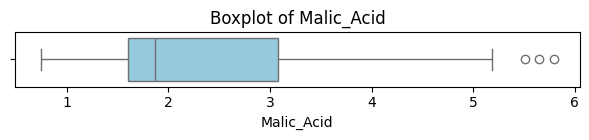

Column: Malic_Acid
IQR Method - Number of outliers: 3
Z-Score Method - Number of outliers: 1


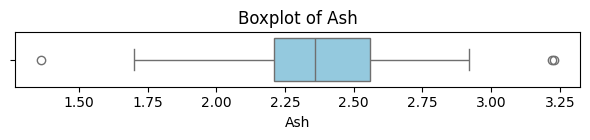

Column: Ash
IQR Method - Number of outliers: 3
Z-Score Method - Number of outliers: 3


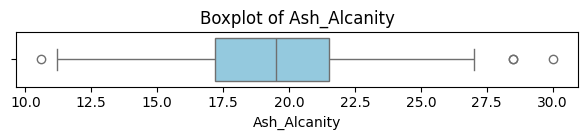

Column: Ash_Alcanity
IQR Method - Number of outliers: 4
Z-Score Method - Number of outliers: 1


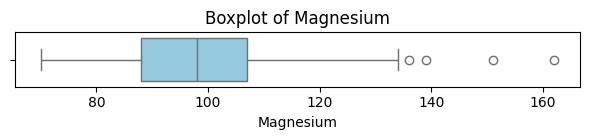

Column: Magnesium
IQR Method - Number of outliers: 4
Z-Score Method - Number of outliers: 2


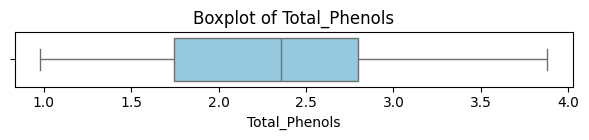

Column: Total_Phenols
IQR Method - Number of outliers: 0
Z-Score Method - Number of outliers: 0


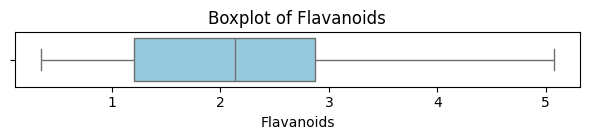

Column: Flavanoids
IQR Method - Number of outliers: 0
Z-Score Method - Number of outliers: 1


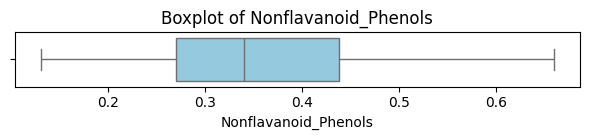

Column: Nonflavanoid_Phenols
IQR Method - Number of outliers: 0
Z-Score Method - Number of outliers: 0


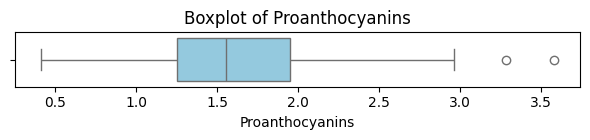

Column: Proanthocyanins
IQR Method - Number of outliers: 2
Z-Score Method - Number of outliers: 1


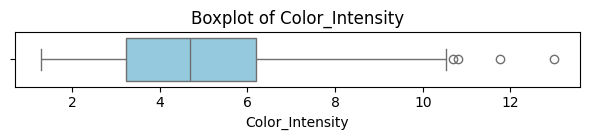

Column: Color_Intensity
IQR Method - Number of outliers: 4
Z-Score Method - Number of outliers: 1


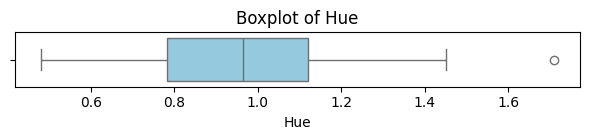

Column: Hue
IQR Method - Number of outliers: 1
Z-Score Method - Number of outliers: 1


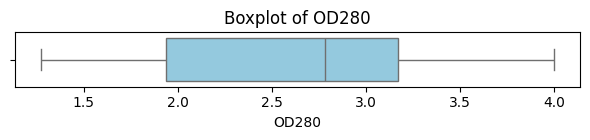

Column: OD280
IQR Method - Number of outliers: 0
Z-Score Method - Number of outliers: 0


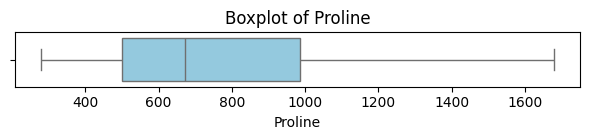

Column: Proline
IQR Method - Number of outliers: 0
Z-Score Method - Number of outliers: 0


In [4]:
descriptor_cols = ['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
                   'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins',
                   'Color_Intensity', 'Hue', 'OD280', 'Proline']

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

def detect_outliers_zscore(df, column, threshold=3):
    z_scores = np.abs(stats.zscore(df[column]))
    outliers = df[z_scores > threshold]
    return outliers

for col in descriptor_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

    detect_outliers = detect_outliers_iqr(df, col)
    z_score_outliers = detect_outliers_zscore(df, col)

    print(f'Column: {col}')
    print(f'IQR Method - Number of outliers: {len(detect_outliers)}')
    print(f'Z-Score Method - Number of outliers: {len(z_score_outliers)}')

In [5]:
# Phương án 1: Loại bỏ outliers
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

df_no_outliers = remove_outliers_iqr(df, descriptor_cols)
print(f"Số dòng ban đầu: {len(df)}")
print(f"Số dòng sau khi loại outliers: {len(df_no_outliers)}")

Số dòng ban đầu: 178
Số dòng sau khi loại outliers: 161


In [6]:
df_clean = remove_outliers_iqr(df, descriptor_cols)

# Lấy dữ liệu đã xử lý outliers
X = df_clean[descriptor_cols].values

# Chuẩn hóa (Z-score standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dữ liệu sau chuẩn hóa:")
print(f"Mean: {X_scaled.mean(axis=0)}")  # Gần 0
print(f"Std: {X_scaled.std(axis=0)}")    # Gần 1

Dữ liệu sau chuẩn hóa:
Mean: [ 3.08931624e-15 -1.76532357e-16  7.61295788e-16 -4.41330892e-17
 -2.42731990e-16 -1.32399268e-16 -2.64798535e-16 -3.08931624e-16
  0.00000000e+00  2.35836195e-16  8.82661784e-16 -1.32399268e-16
 -1.76532357e-16]
Std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
# Chuẩn hóa
X = df_clean[descriptor_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chuyển thành DataFrame để dễ xem
df_scaled = pd.DataFrame(X_scaled, 
                         columns=descriptor_cols,
                         index=df_clean.index)

print("="*80)
print("DỮ LIỆU SAU CHUẨN HÓA (DataFrame)")
print("="*80)
print(df_scaled)

print("\n" + "="*80)
print("5 DÒNG ĐẦU TIÊN")
print(df_scaled.head())


DỮ LIỆU SAU CHUẨN HÓA (DataFrame)
      Alcohol  Malic_Acid       Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    1.515163   -0.579166  0.270936     -1.248144   2.298023       0.828643   
1    0.209648   -0.512507 -0.931537     -2.732175   0.114047       0.589411   
2    0.158948    0.039806  1.266087     -0.236305   0.194935       0.828643   
3    1.692612   -0.350622  0.561189     -0.843409   1.165591       2.503264   
4    0.260347    0.258826  2.095379      0.573166   1.570031       0.828643   
..        ...         ...       ...           ...        ...            ...   
172  1.426439    0.182645  0.478259      0.235886  -0.613945      -0.957620   
174  0.463146    1.515815  0.478259      1.247725   0.275823      -0.766235   
175  0.298372    1.868152 -0.433962      0.235886   1.731807      -1.101159   
176  0.171623    0.258826  0.022149      0.235886   1.731807      -1.005466   
177  1.388414    1.696745  1.556339      1.753645  -0.209505      -0.367515   

     Flavanoids  

In [8]:
df = df_scaled.copy()
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.515163,-0.579166,0.270936,-1.248144,2.298023,0.828643,1.055948,-0.650569,1.466583,0.282097,0.383333,1.828097,0.982174
1,0.209648,-0.512507,-0.931537,-2.732175,0.114047,0.589411,0.749315,-0.815257,-0.505150,-0.304357,0.429479,1.096928,0.934830
2,0.158948,0.039806,1.266087,-0.236305,0.194935,0.828643,1.239928,-0.485881,2.481732,0.300715,0.337186,0.773526,1.360929
3,1.692612,-0.350622,0.561189,-0.843409,1.165591,2.503264,1.495455,-0.979945,1.251840,1.287448,-0.447308,1.167233,2.292034
4,0.260347,0.258826,2.095379,0.573166,1.570031,0.828643,0.677767,0.255215,0.549044,-0.332284,0.383333,0.436064,-0.059401


In [9]:
df_1 = df.copy()
df_2 = df[['Alcohol','Flavanoids', 'Total_Phenols', 'Color_Intensity', 'OD280', 'Proline']].copy()

df_1.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.515163,-0.579166,0.270936,-1.248144,2.298023,0.828643,1.055948,-0.650569,1.466583,0.282097,0.383333,1.828097,0.982174
1,0.209648,-0.512507,-0.931537,-2.732175,0.114047,0.589411,0.749315,-0.815257,-0.505150,-0.304357,0.429479,1.096928,0.934830
2,0.158948,0.039806,1.266087,-0.236305,0.194935,0.828643,1.239928,-0.485881,2.481732,0.300715,0.337186,0.773526,1.360929
3,1.692612,-0.350622,0.561189,-0.843409,1.165591,2.503264,1.495455,-0.979945,1.251840,1.287448,-0.447308,1.167233,2.292034
4,0.260347,0.258826,2.095379,0.573166,1.570031,0.828643,0.677767,0.255215,0.549044,-0.332284,0.383333,0.436064,-0.059401


In [10]:
df_2.head()

,Alcohol,Flavanoids,Total_Phenols,Color_Intensity,OD280,Proline
0,1.515163,1.055948,0.828643,0.282097,1.828097,0.982174
1,0.209648,0.749315,0.589411,-0.304357,1.096928,0.934830
2,0.158948,1.239928,0.828643,0.300715,0.773526,1.360929
3,1.692612,1.495455,2.503264,1.287448,1.167233,2.292034
4,0.260347,0.677767,0.828643,-0.332284,0.436064,-0.059401


In [ ]:
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU VÀ CÁC THAM SỐ

print(f"✓ df_2 shape: {df_2.shape} (6 features chọn lọc)")

# Chọn data để phân cụm 
X = df_2.values
N, p = X.shape

K_values = range(2, 8)

K = 3
# ---------------------

print(f"\n✓ Số mẫu (N): {N}")
print(f"✓ Số chiều (p): {p}")
print(f"✓ Dải số cụm sẽ được kiểm tra (K): {list(K_values)}")
print(f"✓ Ví dụ khởi tạo sẽ được thực hiện với K = {K}")



# BƯỚC 2: VÍ DỤ KHỞI TẠO THAM SỐ (với K đã chọn)
print(f"BƯỚC 2: VÍ DỤ KHỞI TẠO THAM SỐ (VỚI K = {K})")

np.random.seed(42)

# P_k: Xác suất tiên nghiệm (prior probabilities)
# Khởi tạo đồng đều cho K cụm
P = np.ones(K) / K
print(f"\n✓ P_k (xác suất tiên nghiệm):\n{P}")

# mu_k: Trung bình của mỗi cụm (mean vectors)
# Khởi tạo ngẫu nhiên từ dữ liệu
random_idx = np.random.choice(N, K, replace=False)
mu = X[random_idx]
print(f"\n✓ μ_k (trung bình các cụm):\n{mu}")

# Sigma_k: Ma trận hiệp phương sai của mỗi cụm (covariance matrices)
# Khởi tạo là ma trận đơn vị nhân với phương sai mẫu
sigma = [np.eye(p) * np.var(X) for _ in range(K)]
print(f"\n✓ Σ_k đã được khởi tạo (shape: {p}x{p} cho mỗi cụm)")



# BƯỚC 3: XÂY DỰNG HÀM F_MIX(x) - MẬT ĐỘ HỖN HỢP

print("BƯỚC 3: XÂY DỰNG HÀM F_MIX(x)")

from scipy.stats import multivariate_normal
from scipy.special import logsumexp

def gaussian_pdf(x, mu, sigma):
    """Hàm mật độ xác suất Gaussian đa biến."""
    return multivariate_normal.pdf(x, mean=mu, cov=sigma, allow_singular=True)

def f_mix(x, P, mu, sigma, K):
    """Hàm mật độ hỗn hợp (Mixture density function)."""
    density = 0
    for k in range(K):
        density += P[k] * gaussian_pdf(x, mu[k], sigma[k])
    return density

# Kiểm tra hàm f_mix với một mẫu và các tham số đã khởi tạo
sample_density = f_mix(X[0], P, mu, sigma, K)
print(f"\n✓ Hàm F_mix đã được định nghĩa")
print(f"✓ Ví dụ: F_mix(x[0]) với K={K} là {sample_density:.6f}")

✓ df_1 shape: (161, 13) (tất cả features)
✓ df_2 shape: (161, 6) (6 features chọn lọc)

✓ Số mẫu (N): 161
✓ Số chiều (p): 6
✓ Dải số cụm sẽ được kiểm tra (K): [2, 3, 4, 5, 6, 7]
✓ Ví dụ khởi tạo sẽ được thực hiện với K = 3
BƯỚC 2: VÍ DỤ KHỞI TẠO THAM SỐ (VỚI K = 3)

✓ P_k (xác suất tiên nghiệm):
[0.33333333 0.33333333 0.33333333]

✓ μ_k (trung bình các cụm):
[[-2.05916095 -0.01726795  0.31828206 -0.90942989 -0.43571444 -1.00944401]
 [-0.77899517  0.06450087 -0.4472591  -1.38417901  0.4782466  -1.29035374]
 [ 1.02084188 -1.22335804 -0.76623459  1.85063116 -1.37779736 -0.86425471]]

✓ Σ_k đã được khởi tạo (shape: 6x6 cho mỗi cụm)
BƯỚC 3: XÂY DỰNG HÀM F_MIX(x)

✓ Hàm F_mix đã được định nghĩa
✓ Ví dụ: F_mix(x[0]) với K=3 là 0.000000


In [12]:
# BƯỚC 4: ĐỊNH NGHĨA HÀM E-STEP VỚI LOG-SPACE

print("BƯỚC 4: ĐỊNH NGHĨA HÀM E-STEP")

from scipy.special import logsumexp
from scipy.stats import multivariate_normal

def e_step_logspace(X, mu, Sigma_list, p_k):
    """
    E-step sử dụng log-space để tránh underflow.
    """
    N, p = X.shape
    K = len(Sigma_list)
    log_resp = np.zeros((N, K))
    
    for k in range(K):
        log_resp[:, k] = multivariate_normal.logpdf(
            X, mean=mu[k], cov=Sigma_list[k], allow_singular=True
        ) + np.log(p_k[k] + 1e-300)
    
    ll_per_obs = logsumexp(log_resp, axis=1)
    log_tau = log_resp - ll_per_obs[:, None]
    tau = np.exp(log_tau)
    ll = np.sum(ll_per_obs)
    
    return tau, ll, log_tau

print("\n✓ Hàm E-step (e_step_logspace) đã được định nghĩa.")

# BƯỚC 5: ĐỊNH NGHĨA HÀM M-STEP VỚI CÁC CẤU TRÚC COVARIANCE

print("BƯỚC 5: ĐỊNH NGHĨA HÀM M-STEP")

def m_step_updates(X, tau, cov_type='full', min_covar=1e-3):
    """
    M-step: Cập nhật tham số với các cấu trúc covariance khác nhau.
    """
    N, p = X.shape
    K = tau.shape[1]
    
    Nk = tau.sum(axis=0) + 1e-10
    p_k = Nk / N
    mu = (tau.T @ X) / Nk[:, None]
    
    Sigma_list = []
    
    if cov_type == 'spherical_equal':
        total_variance = 0
        for k in range(K):
            diff = X - mu[k]
            total_variance += np.sum(tau[:, k].reshape(-1, 1) * (diff ** 2))
        variance = max(total_variance / (N * p), min_covar)
        Sigma_list = [np.eye(p) * variance for _ in range(K)]
        
    elif cov_type == 'spherical_varying':
        for k in range(K):
            diff = X - mu[k]
            variance_k = np.sum(tau[:, k].reshape(-1, 1) * (diff ** 2)) / (Nk[k] * p)
            Sigma_list.append(np.eye(p) * max(variance_k, min_covar))
            
    elif cov_type == 'diagonal':
        for k in range(K):
            diff = X - mu[k]
            weighted_var = np.sum(tau[:, k].reshape(-1, 1) * (diff ** 2), axis=0) / Nk[k]
            Sigma_list.append(np.diag(np.maximum(weighted_var, min_covar)))
            
    elif cov_type == 'full':
        for k in range(K):
            X_centered = X - mu[k]
            S = (tau[:, k][:, None] * X_centered).T @ X_centered / Nk[k]
            S += min_covar * np.eye(p)
            Sigma_list.append(S)
            
    else:
        raise ValueError(f"Unknown cov_type: {cov_type}")
    
    return p_k, mu, Sigma_list

print("\n✓ Hàm M-step (m_step_updates) đã được định nghĩa.")

# BƯỚC 6: ĐỊNH NGHĨA THUẬT TOÁN EM HOÀN CHỈNH
print("BƯỚC 6: ĐỊNH NGHĨA THUẬT TOÁN EM")


def em_algorithm(X, K, cov_type='full', max_iter=100, tol=1e-4, verbose=True):
    """
    Thuật toán EM để tối ưu GMM với các cấu trúc covariance.
    """
    N, p = X.shape
    np.random.seed(42) # Để đảm bảo tính nhất quán khi khởi tạo
    
    # Khởi tạo tham số
    P = np.ones(K) / K
    random_idx = np.random.choice(N, K, replace=False)
    mu = X[random_idx]
    
    if cov_type == 'spherical_equal' or cov_type == 'spherical_varying':
        sigma = [np.eye(p) * np.var(X) for _ in range(K)]
    elif cov_type == 'diagonal':
        sigma = [np.diag(np.var(X, axis=0)) for _ in range(K)]
    else: # full
        sigma = [np.cov(X.T) + np.eye(p) * 1e-3 for _ in range(K)]
    
    log_L_history = []
    prev_log_L = -np.inf
    
    for iteration in range(max_iter):
        # E-STEP
        gamma, log_L, _ = e_step_logspace(X, mu, sigma, P)
        log_L_history.append(log_L)
        
        if verbose and iteration % 10 == 0:
            print(f"  Iteration {iteration}: Log-likelihood = {log_L:.4f}")
        
        if abs(log_L - prev_log_L) < tol and iteration > 0:
            if verbose:
                print(f"  ✓ Hội tụ tại iteration {iteration}")
            break
        prev_log_L = log_L
        
        # M-STEP
        P, mu, sigma = m_step_updates(X, gamma, cov_type=cov_type)
    
    return P, mu, sigma, gamma, log_L_history

print("\n✓ Hàm chính (em_algorithm) đã được định nghĩa.")
print("✅ TẤT CẢ CÁC HÀM CẦN THIẾT ĐÃ SẴN SÀNG ĐỂ SỬ DỤNG.")

BƯỚC 4: ĐỊNH NGHĨA HÀM E-STEP

✓ Hàm E-step (e_step_logspace) đã được định nghĩa.
BƯỚC 5: ĐỊNH NGHĨA HÀM M-STEP

✓ Hàm M-step (m_step_updates) đã được định nghĩa.
BƯỚC 6: ĐỊNH NGHĨA THUẬT TOÁN EM

✓ Hàm chính (em_algorithm) đã được định nghĩa.
✅ TẤT CẢ CÁC HÀM CẦN THIẾT ĐÃ SẴN SÀNG ĐỂ SỬ DỤNG.


In [ ]:
# BƯỚC 7: ĐỊNH NGHĨA HÀM BÁO CÁO 

# Ghi chú: Chúng ta chỉ định nghĩa hàm này ở đây, nhưng sẽ không gọi nó trong vòng lặp.

print("BƯỚC 7: ĐỊNH NGHĨA HÀM BÁO CÁO KẾT QUẢ")


def report_and_visualize_gmm(X, P, mu, gamma, log_L_history, feature_names):
    """
    Hàm tổng hợp để gán nhãn, in báo cáo và trực quan hóa kết quả GMM.
    """
    N, p = X.shape
    K = P.shape[0]
    cluster_labels = np.argmax(gamma, axis=1)
    
    # ... (Nội dung hàm giữ nguyên như bạn đã cung cấp) ...
    print("\n" + "=" * 70)
    print(f"✅ PHÂN TÍCH KẾT QUẢ CHI TIẾT CHO K={K}")
    print("=" * 70)
    
    print("\n📌 THỐNG KÊ PHÂN BỐ CỤM:")
    for k in range(K):
        count = np.sum(cluster_labels == k)
        print(f"  - Cụm {k}: {count} điểm ({count/N*100:.1f}%)")
        
    print("\n📌 THAM SỐ MÔ HÌNH HỌC ĐƯỢC:")
    print(f"  - Trọng số P_k: {np.round(P, 3)}")
    for k in range(K):
        print(f"  - Trung bình μ_{k}: {np.round(mu[k], 2)}")
        
    print("\n📊 Đang tạo biểu đồ trực quan hóa...")
    # (Toàn bộ code vẽ vời giữ nguyên)
    # ...
    plt.show() # Chỉ hiển thị, không lưu file trong lần chạy này

print("✓ Hàm report_and_visualize_gmm đã được định nghĩa và sẵn sàng để sử dụng sau.")



BƯỚC 7: ĐỊNH NGHĨA HÀM BÁO CÁO KẾT QUẢ
✓ Hàm report_and_visualize_gmm đã được định nghĩa và sẵn sàng để sử dụng sau.


BƯỚC 8: CHẠY THỬ NGHIỆM VỚI K TỪ 2 ĐẾN 7

--- Đang chạy thuật toán cho K = 2 (cấu trúc: full) ---
✓ Hoàn thành K = 2:
  - Log-Likelihood cuối cùng: -850.7366
  - Hội tụ sau 29 vòng lặp.

--- Đang chạy thuật toán cho K = 3 (cấu trúc: full) ---
✓ Hoàn thành K = 3:
  - Log-Likelihood cuối cùng: -811.2131
  - Hội tụ sau 32 vòng lặp.

--- Đang chạy thuật toán cho K = 4 (cấu trúc: full) ---
✓ Hoàn thành K = 4:
  - Log-Likelihood cuối cùng: -761.2368
  - Hội tụ sau 36 vòng lặp.

--- Đang chạy thuật toán cho K = 5 (cấu trúc: full) ---
✓ Hoàn thành K = 5:
  - Log-Likelihood cuối cùng: -729.4851
  - Hội tụ sau 53 vòng lặp.

--- Đang chạy thuật toán cho K = 6 (cấu trúc: full) ---
✓ Hoàn thành K = 6:
  - Log-Likelihood cuối cùng: -721.2683
  - Hội tụ sau 45 vòng lặp.

--- Đang chạy thuật toán cho K = 7 (cấu trúc: full) ---
✓ Hoàn thành K = 7:
  - Log-Likelihood cuối cùng: -693.3174
  - Hội tụ sau 51 vòng lặp.
BƯỚC 9: TRỰC QUAN HÓA SỰ THAY ĐỔI CỦA LOG-LIKELIHOOD THEO K


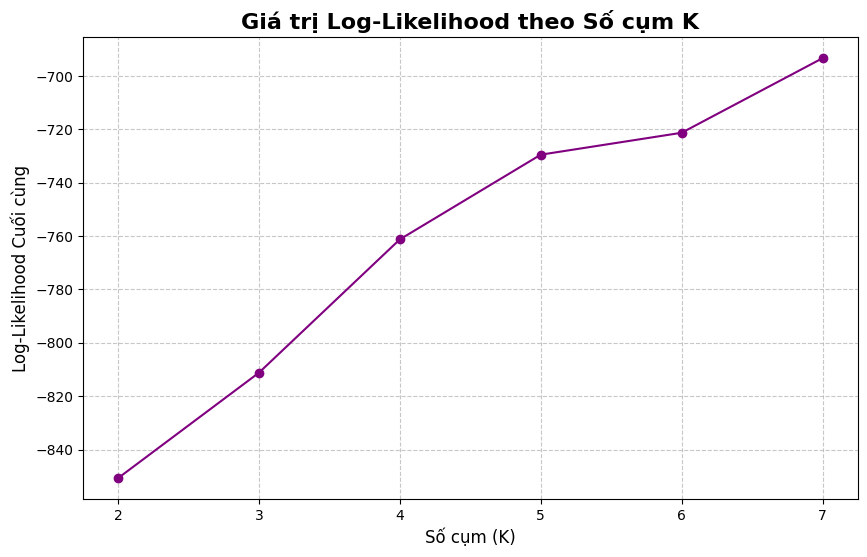


 nhận xét: Có thể thấy rằng log-likelihood luôn có xu hướng tăng khi K tăng.
Điều này là tự nhiên vì mô hình phức tạp hơn sẽ luôn 'khớp' (fit) với dữ liệu tốt hơn.
Đây là lý do chúng ta cần các tiêu chí như BIC/AIC ở bước tiếp theo để phạt sự phức tạp này và tìm ra K tối ưu.


In [14]:
# BƯỚC 8: CHẠY THỬ NGHIỆM VÀ SO SÁNH LOG-LIKELIHOOD

print("BƯỚC 8: CHẠY THỬ NGHIỆM VỚI K TỪ 2 ĐẾN 7")

# Giả sử các hàm `em_algorithm` và dữ liệu `X` đã được định nghĩa ở các cell trước

# Dải giá trị K cần kiểm tra
k_values = range(2, 8)
final_log_likelihoods = {} # Dùng dictionary để lưu K và kết quả tương ứng

# Chọn một cấu trúc covariance để thử nghiệm, ví dụ: 'full'
covariance_type_to_test = 'full'



for k in k_values:
    print(f"\n--- Đang chạy thuật toán cho K = {k} (cấu trúc: {covariance_type_to_test}) ---")
    
    # Chạy thuật toán EM cho giá trị k hiện tại
    # Tắt 'verbose' để output của vòng lặp gọn gàng hơn
    _, _, _, _, log_L_history = em_algorithm(
        X, 
        K=k, 
        cov_type=covariance_type_to_test, 
        verbose=False
    )
    
    # Lấy giá trị log-likelihood cuối cùng (giá trị hội tụ)
    final_log_L = log_L_history[-1]
    final_log_likelihoods[k] = final_log_L
    
    print(f"✓ Hoàn thành K = {k}:")
    print(f"  - Log-Likelihood cuối cùng: {final_log_L:.4f}")
    print(f"  - Hội tụ sau {len(log_L_history)} vòng lặp.")


# BƯỚC 9: TRỰC QUAN HÓA KẾT QUẢ LOG-LIKELIHOOD

print("BƯỚC 9: TRỰC QUAN HÓA SỰ THAY ĐỔI CỦA LOG-LIKELIHOOD THEO K")

# Chuyển dictionary sang list để vẽ
k_list = list(final_log_likelihoods.keys())
log_L_list = list(final_log_likelihoods.values())

plt.figure(figsize=(10, 6))
plt.plot(k_list, log_L_list, marker='o', linestyle='-', color='purple')
plt.title('Giá trị Log-Likelihood theo Số cụm K', fontsize=16, fontweight='bold')
plt.xlabel('Số cụm (K)', fontsize=12)
plt.ylabel('Log-Likelihood Cuối cùng', fontsize=12)
plt.xticks(k_list)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\n nhận xét: Có thể thấy rằng log-likelihood luôn có xu hướng tăng khi K tăng.")
print("Điều này là tự nhiên vì mô hình phức tạp hơn sẽ luôn 'khớp' (fit) với dữ liệu tốt hơn.")
print("Đây là lý do chúng ta cần các tiêu chí như BIC/AIC ở bước tiếp theo để phạt sự phức tạp này và tìm ra K tối ưu.")

In [15]:
# CÁC CẤU TRÚC MA TRẬN HIỆP PHƯƠNG SAI 

print("CÁC CẤU TRÚC MA TRẬN HIỆP PHƯƠNG SAI (ĐÃ CHUẨN HÓA CÔNG THỨC)")

# Công thức tính tham số được viết lại theo dạng chuẩn:
# M = (K-1) [trộn] + (K*p) [trung bình] + (#cov_params) [hiệp phương sai]

covariance_structures = {
    'spherical_equal': {
        'name': 'EII (Spherical, Equal Volume)',
        'description': 'Tất cả cụm có cùng phương sai, hình cầu.',
        # #cov_params = 1 (chỉ một giá trị phương sai)
        'n_params_formula': '(K - 1) + (K * p) + 1'
    },
    'spherical_varying': {
        'name': 'VII (Spherical, Variable Volume)',
        'description': 'Mỗi cụm có phương sai khác nhau, hình cầu.',
        # #cov_params = K (mỗi cụm một giá trị phương sai)
        'n_params_formula': '(K - 1) + (K * p) + K'
    },
    'diagonal': {
        'name': 'VVI (Diagonal, Variable Volume & Shape)',
        'description': 'Mỗi cụm có ma trận hiệp phương sai chéo riêng.',
        # #cov_params = K * p (mỗi cụm có p phương sai trên đường chéo)
        'n_params_formula': '(K - 1) + (K * p) + (K * p)'
    },
    'full': {
        'name': 'VVV (Ellipsoidal, Unrestricted)',
        'description': 'Mỗi cụm có ma trận hiệp phương sai đầy đủ riêng.',
        # #cov_params = K * p * (p+1)/2
        'n_params_formula': '(K - 1) + (K * p) + (K * p * (p + 1) / 2)'
    }
}

for key, info in covariance_structures.items():
    print(f"\n{key.upper()}:")
    print(f"  • Tên mô hình: {info['name']}")
    print(f"  • Mô tả: {info['description']}")
    print(f"  • Công thức tính tham số M: {info['n_params_formula']}")

CÁC CẤU TRÚC MA TRẬN HIỆP PHƯƠNG SAI (ĐÃ CHUẨN HÓA CÔNG THỨC)

SPHERICAL_EQUAL:
  • Tên mô hình: EII (Spherical, Equal Volume)
  • Mô tả: Tất cả cụm có cùng phương sai, hình cầu.
  • Công thức tính tham số M: (K - 1) + (K * p) + 1

SPHERICAL_VARYING:
  • Tên mô hình: VII (Spherical, Variable Volume)
  • Mô tả: Mỗi cụm có phương sai khác nhau, hình cầu.
  • Công thức tính tham số M: (K - 1) + (K * p) + K

DIAGONAL:
  • Tên mô hình: VVI (Diagonal, Variable Volume & Shape)
  • Mô tả: Mỗi cụm có ma trận hiệp phương sai chéo riêng.
  • Công thức tính tham số M: (K - 1) + (K * p) + (K * p)

FULL:
  • Tên mô hình: VVV (Ellipsoidal, Unrestricted)
  • Mô tả: Mỗi cụm có ma trận hiệp phương sai đầy đủ riêng.
  • Công thức tính tham số M: (K - 1) + (K * p) + (K * p * (p + 1) / 2)


In [16]:
# HÀM TÍNH SỐ THAM SỐ

def count_parameters(K, p, cov_type):
    """
    Trả về số tham số toàn phần M cho mô hình GMM với K components, chiều p,
    và cấu trúc covariance 'cov_type' (chuẩn theo mclust-like codes).
    K: int, p: int, cov_type: str (one of 'EII','VII','EEI','VVI','EEE','VVV','VEI','EVI','VEE','EVE')
    """
    # mixing proportions: K-1
    mix = max(K - 1, 0)
    # means: K * p
    means = K * p

    cov_params = None
    ct = cov_type.lower()
    if ct in ('eii','spherical_equal'):
        # Equal volume, spherical: one variance shared
        cov_params = 1
    elif ct in ('vii','spherical_varying'):
        # Variable volume, spherical: one variance per component
        cov_params = K
    elif ct in ('eei','diagonal_equal'):
        # Equal volume, equal shape, diagonal: p parameters (common diagonal)
        cov_params = p
    elif ct in ('vvi','diagonal_varying'):
        # Variable volume, variable shape, diagonal: K * p
        cov_params = K * p
    elif ct in ('eee','full_equal'):
        # Equal volume, equal shape, equal orientation: common full covariance
        cov_params = p * (p + 1) // 2
    elif ct in ('vvv','full_varying'):
        # Full, each component has full covariance
        cov_params = K * p * (p + 1) // 2
    elif ct in ('vei',):
        # Variable volume, equal shape, diagonal orientation - approx:
        cov_params = K + (p - 1)
    elif ct in ('evi',):
        cov_params = 1 + K * (p - 1)
    elif ct in ('vee','v e e','v e e'.replace(' ','').lower()):
        cov_params = K + p*(p-1)//2
    else:
        # fallback: assume full per component
        cov_params = K * p * (p + 1) // 2

    M = mix + means + cov_params
    return M


def compute_aic_bic_icl(loglik, N, M, tau):
    """
    loglik: scalar (natural log, i.e., sum_j log(sum_k p_k f_k(x_j)))
    Return AIC, BIC, ICL in -2lnL + penalty form (smaller is better).
    """
    neg2ll = -2.0 * loglik
    aic = neg2ll + 2.0 * M
    bic = neg2ll + M * np.log(N)
    entropy = np.sum(tau * np.log(np.clip(tau, 1e-300, None)))
    icl = bic - 2.0 * entropy  # since entropy is negative, this increases penalty
    return aic, bic, icl


print("\n✓ Hàm count_parameters và compute_aic_bic_icl đã được định nghĩa")


✓ Hàm count_parameters và compute_aic_bic_icl đã được định nghĩa


In [17]:
# M-STEP VỚI CONSTRAINT

print("M-STEP VỚI CONSTRAINT")

def ensure_well_conditioned(Sigma, min_covar=1e-6, cond_thresh=1e12):
    """Đảm bảo ma trận hiệp phương sai ổn định về mặt số học."""
    try:
        S = Sigma + min_covar * np.eye(Sigma.shape[0])
        cond = np.linalg.cond(S)
        if cond > cond_thresh:
            factor = cond / cond_thresh
            S += (min_covar * factor) * np.eye(S.shape[0])
        return S
    except np.linalg.LinAlgError:
        # Trong trường hợp cực kỳ hiếm, trả về một ma trận an toàn
        return np.eye(Sigma.shape[0]) * min_covar
    
    
def m_step_with_constraint(X, tau, cov_type='full', min_covar=1e-3):
    """
    M-step với ràng buộc cấu trúc covariance
    """
    N, p = X.shape
    K = tau.shape[1]
    
    N_k = tau.sum(axis=0) + 1e-10
    p_k = N_k / N
    mu = np.dot(tau.T, X) / N_k[:, None]
    
    Sigma_list = []
    
    if cov_type == 'spherical_equal':
        total_variance = 0
        for k in range(K):
            diff = X - mu[k]
            total_variance += np.sum(tau[:, k].reshape(-1, 1) * (diff ** 2))
        variance = total_variance / (N * p)
        variance = max(variance, min_covar)
        Sigma_list = [np.eye(p) * variance for _ in range(K)]
        
    elif cov_type == 'spherical_varying':
        for k in range(K):
            diff = X - mu[k]
            variance_k = np.sum(tau[:, k].reshape(-1, 1) * (diff ** 2)) / (N_k[k] * p)
            variance_k = max(variance_k, min_covar)
            Sigma_list.append(np.eye(p) * variance_k)
            
    elif cov_type == 'diagonal':
        for k in range(K):
            diff = X - mu[k]
            weighted_var = np.sum(tau[:, k].reshape(-1, 1) * (diff ** 2), axis=0) / N_k[k]
            weighted_var = np.clip(weighted_var, min_covar, None)
            Sigma_list.append(np.diag(weighted_var))
            
    else:  # full
        for k in range(K):
            diff = X - mu[k]
            weighted_diff = tau[:, k].reshape(-1, 1) * diff
            S_raw = (weighted_diff.T @ diff) / N_k[k] # Tính ma trận S "thô"
            
            S_stable = ensure_well_conditioned(S_raw, min_covar=min_covar, cond_thresh=1e12)
            # --------------------
            
            Sigma_list.append(S_stable)
    
    return p_k, mu, Sigma_list

print("\n✓ Hàm m_step_with_constraint đã được định nghĩa")


# THUẬT TOÁN EM CHO TỪNG CẤU TRÚC COVARIANCE

print("THUẬT TOÁN EM CHO TỪNG CẤU TRÚC COVARIANCE")


def em_with_cov_structure(X, K, cov_type='full', max_iter=100, tol=1e-4, verbose=False):
    """
    EM algorithm với ràng buộc cấu trúc covariance (DÙNG LOG-SPACE)
    """
    N, p = X.shape
    np.random.seed(42)
    
    P = np.ones(K) / K
    random_idx = np.random.choice(N, K, replace=False)
    mu = X[random_idx]
    
    if cov_type == 'spherical_equal':
        variance = np.var(X)
        sigma = [np.eye(p) * variance for _ in range(K)]
    elif cov_type == 'spherical_varying':
        sigma = [np.eye(p) * np.var(X) for _ in range(K)]
    elif cov_type == 'diagonal':
        sigma = [np.diag(np.var(X, axis=0)) for _ in range(K)]
    else:  # full
        sigma = [np.cov(X.T) + np.eye(p) * 1e-3 for _ in range(K)]
    
    prev_log_L = -np.inf
    
    for iteration in range(max_iter):
        gamma, log_L, log_tau = e_step_logspace(X, mu, sigma, P)
        
        if verbose and iteration % 25 == 0:
            print(f"    Iteration {iteration}: Log-likelihood = {log_L:.4f}")
        
        if iteration > 0:
            if log_L < prev_log_L - 1e-6:
                import warnings
                warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")
            
            if abs(log_L - prev_log_L) < tol:
                if verbose:
                    print(f"    ✓ Hội tụ tại iteration {iteration}")
                break
        
        prev_log_L = log_L
        P, mu, sigma = m_step_with_constraint(X, gamma, cov_type=cov_type)
    
    return P, mu, sigma, gamma, log_L

print("\n✓ Hàm em_with_cov_structure đã được định nghĩa")



M-STEP VỚI CONSTRAINT

✓ Hàm m_step_with_constraint đã được định nghĩa
THUẬT TOÁN EM CHO TỪNG CẤU TRÚC COVARIANCE

✓ Hàm em_with_cov_structure đã được định nghĩa


BẮT ĐẦU QUÁ TRÌNH GRID SEARCH TÌM MÔ HÌNH TỐI ƯU
• Số cụm K sẽ được thử nghiệm: [2, 3, 4, 5]
• Các cấu trúc covariance: 4 loại
• Tổng số mô hình sẽ được huấn luyện: 16

🔄 Đang chạy: K=2, Cấu trúc='spherical_equal'...
  ✓ Kết quả: BIC= 2491.03, LogL=-1209.95, Params=14

🔄 Đang chạy: K=2, Cấu trúc='spherical_varying'...
  ✓ Kết quả: BIC= 2428.47, LogL=-1176.12, Params=15

🔄 Đang chạy: K=2, Cấu trúc='diagonal'...
  ✓ Kết quả: BIC= 2494.52, LogL=-1107.52, Params=55

🔄 Đang chạy: K=2, Cấu trúc='full'...
  ✓ Kết quả: BIC= 1980.95, LogL= -850.74, Params=55

🔄 Đang chạy: K=3, Cấu trúc='spherical_equal'...
  ✓ Kết quả: BIC= 2117.18, LogL=-1005.24, Params=21

🔄 Đang chạy: K=3, Cấu trúc='spherical_varying'...
  ✓ Kết quả: BIC= 2126.97, LogL=-1005.05, Params=23

🔄 Đang chạy: K=3, Cấu trúc='diagonal'...
  ✓ Kết quả: BIC= 2268.84, LogL= -923.54, Params=83

🔄 Đang chạy: K=3, Cấu trúc='full'...
  ✓ Kết quả: BIC= 2044.18, LogL= -811.21, Params=83

🔄 Đang chạy: K=4, Cấu trúc='spherical_equal'...
  ✓ Kết

C:\Users\PC\AppData\Local\Temp\ipykernel_15652\1083723589.py:108: UserWarning: ⚠️ Log-likelihood giảm: -850.7366 → -850.7366
  warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_15652\1083723589.py:108: UserWarning: ⚠️ Log-likelihood giảm: -811.2032 → -811.2049
  warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_15652\1083723589.py:108: UserWarning: ⚠️ Log-likelihood giảm: -811.2049 → -811.2071
  warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_15652\1083723589.py:108: UserWarning: ⚠️ Log-likelihood giảm: -811.2071 → -811.2089
  warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_15652\1083723589.py:108: UserWarning: ⚠️ Log-likelihood giảm: -811.2089 → -811.2103
  warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")


  ✓ Kết quả: BIC= 2086.51, LogL= -761.24, Params=111

🔄 Đang chạy: K=5, Cấu trúc='spherical_equal'...
  ✓ Kết quả: BIC= 2037.91, LogL= -930.03, Params=35

🔄 Đang chạy: K=5, Cấu trúc='spherical_varying'...
  ✓ Kết quả: BIC= 2036.02, LogL= -918.92, Params=39

🔄 Đang chạy: K=5, Cấu trúc='diagonal'...
  ✓ Kết quả: BIC= 2414.75, LogL= -854.22, Params=139

🔄 Đang chạy: K=5, Cấu trúc='full'...
  ✓ Kết quả: BIC= 2165.29, LogL= -729.49, Params=139
KẾT QUẢ TỐI ƯU HÓA

📊 Bảng xếp hạng tất cả các mô hình (sắp xếp theo BIC - thấp hơn là tốt hơn):
 K          Cov_Type     BIC     AIC     ICL  Log_Likelihood  N_Params
 2              full 1980.95 1811.47 1986.26         -850.74        55
 5 spherical_varying 2036.02 1915.85 2068.97         -918.92        39
 5   spherical_equal 2037.91 1930.06 2076.80         -930.03        35
 3              full 2044.18 1788.43 2052.83         -811.21        83
 4              full 2086.51 1744.47 2100.31         -761.24       111
 4   spherical_equal 2086.75 2000.

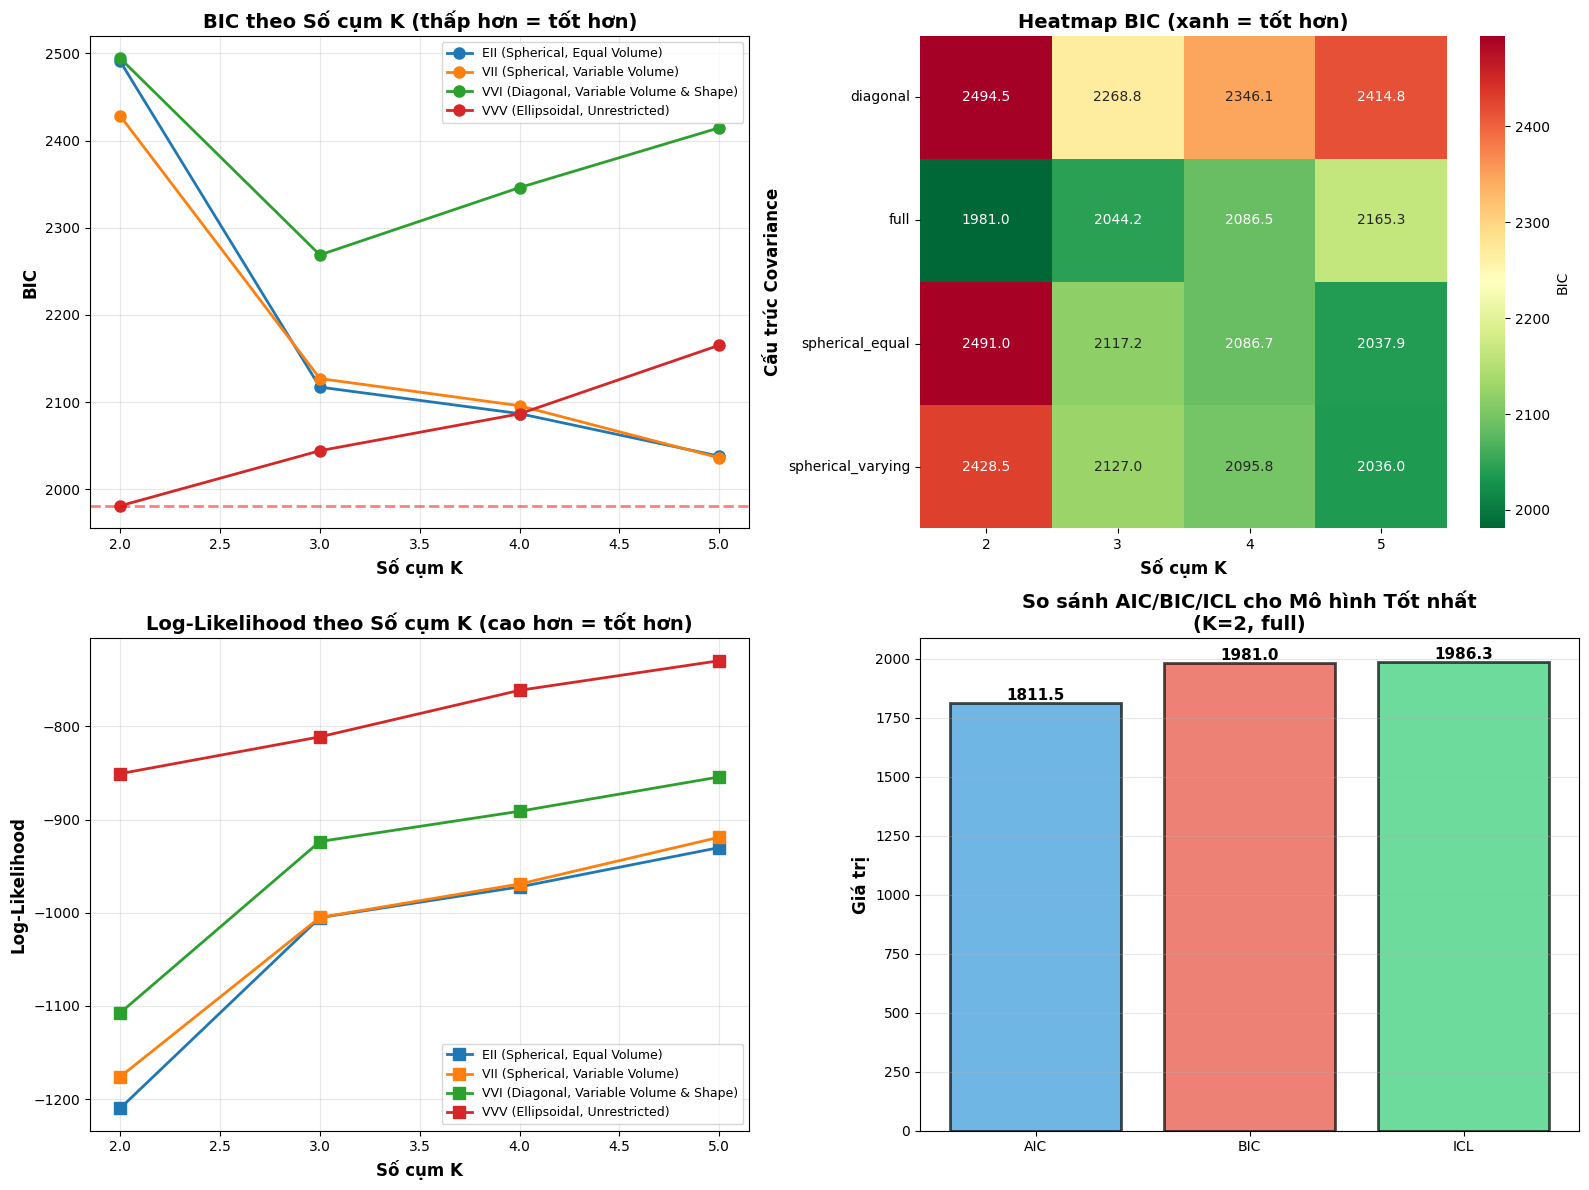



💾 Các biến của mô hình tốt nhất đã được lưu để sử dụng ở bước sau.


In [18]:
# GRID SEARCH - TÌM MÔ HÌNH TỐI ƯU TOÀN DIỆN

import time
import traceback


K_range = range(2, 6)  

cov_types = ['spherical_equal', 'spherical_varying', 'diagonal', 'full']
results = []
N, p = X.shape

print("BẮT ĐẦU QUÁ TRÌNH GRID SEARCH TÌM MÔ HÌNH TỐI ƯU")
print(f"• Số cụm K sẽ được thử nghiệm: {list(K_range)}")
print(f"• Các cấu trúc covariance: {len(cov_types)} loại")
print(f"• Tổng số mô hình sẽ được huấn luyện: {len(K_range) * len(cov_types)}")


import numpy as np

def relabel_by_weight(p_k, mu, Sigma_list):
    """
    Sắp lại thứ tự các component theo p_k giảm dần.
    Trả về p_k_new, mu_new, Sigma_list_new.
    """
    order = np.argsort(-np.array(p_k))  # descending
    p_k_new = np.array(p_k)[order]
    mu_new = np.array(mu)[order]
    Sigma_new = [Sigma_list[i] for i in order]
    return p_k_new, mu_new, Sigma_new


def ensure_well_conditioned(Sigma, min_covar=1e-6, cond_thresh=1e12):
    """
    Đảm bảo ma trận hiệp phương sai Sigma tốt về mặt số học.
    - Thêm min_covar trên đường chéo.
    - Nếu condition number quá lớn, tăng regularization theo tỉ lệ.
    Trả về ma trận đã điều chỉnh.
    """
    p = Sigma.shape[0]
    S = Sigma + min_covar * np.eye(p)
    try:
        cond = np.linalg.cond(S)
    except np.linalg.LinAlgError:
        cond = np.inf
    if cond > cond_thresh:
        # tăng regularization tỉ lệ để giảm condition number
        factor = cond / cond_thresh
        S += (min_covar * factor) * np.eye(p)
    return S

start_time = time.time()
try:
    
    for K in K_range:
        for cov_type in cov_types:
            print(f"\n🔄 Đang chạy: K={K}, Cấu trúc='{cov_type}'...")
            
            try:
                # 1. Chạy thuật toán EM
                P, mu, sigma, gamma, log_L = em_with_cov_structure(
                    X, K, cov_type=cov_type, max_iter=150, tol=1e-4, verbose=False
                )
                
                # 2. Tính số tham số và các tiêu chí
                n_params = count_parameters(K, p, cov_type)
                aic, bic, icl = compute_aic_bic_icl(log_L, N, n_params, gamma)
                
                # 3. Lưu trữ kết quả
                results.append({
                    'K': K,
                    'Cov_Type': cov_type,
                    'Cov_Name': covariance_structures[cov_type]['name'],
                    'Log_Likelihood': log_L,
                    'N_Params': n_params,
                    'AIC': aic,
                    'BIC': bic,
                    'ICL': icl,
                    'Model': (P, mu, sigma, gamma)
                })
                
                print(f"  ✓ Kết quả: BIC={bic:8.2f}, LogL={log_L:8.2f}, Params={n_params}")
                
            except Exception as e:
                print(f"  ✗ LỖI khi chạy mô hình: {str(e)}")
                
    if len(results) == 0:
        raise ValueError("Không có mô hình nào chạy thành công!")
        
    results_df = pd.DataFrame(results).sort_values('BIC', ascending=True)
    
    # HIỂN THỊ KẾT QUẢ
    
    
    print("KẾT QUẢ TỐI ƯU HÓA")
    
    
    
    print("\n📊 Bảng xếp hạng tất cả các mô hình (sắp xếp theo BIC - thấp hơn là tốt hơn):")
    print(results_df[['K', 'Cov_Type', 'BIC', 'AIC', 'ICL', 'Log_Likelihood', 'N_Params']].round(2).to_string(index=False))
    
    
    best_model = results_df.iloc[0]
    print("\n" + "🏆" * 25)
    print("          MÔ HÌNH TỐI ƯU NHẤT          ")
    print("🏆" * 25)
    print(f"\n✓ Số cụm K: {best_model['K']}")
    print(f"✓ Cấu trúc Covariance: {best_model['Cov_Name']}")
    print(f"✓ BIC: {best_model['BIC']:.4f} (Chỉ số quyết định)")
    
    
    # TRỰC QUAN HÓA KẾT QUẢ
    
    print("TRỰC QUAN HÓA")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: BIC theo K cho từng cov_type
    ax = axes[0, 0]
    for cov_type in cov_types:
        subset = results_df[results_df['Cov_Type'] == cov_type].sort_values('K')
        if len(subset) > 0:
            ax.plot(subset['K'], subset['BIC'], marker='o', linewidth=2, 
                label=covariance_structures[cov_type]['name'], markersize=8)
    ax.set_xlabel('Số cụm K', fontsize=12, fontweight='bold')
    ax.set_ylabel('BIC', fontsize=12, fontweight='bold')
    ax.set_title('BIC theo Số cụm K (thấp hơn = tốt hơn)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=best_model['BIC'], color='red', linestyle='--', linewidth=2, alpha=0.5)

    # Plot 2: Heatmap BIC
    ax = axes[0, 1]
    pivot_bic = results_df.pivot(index='Cov_Type', columns='K', values='BIC')
    sns.heatmap(pivot_bic, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, 
            cbar_kws={'label': 'BIC'})
    ax.set_xlabel('Số cụm K', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cấu trúc Covariance', fontsize=12, fontweight='bold')
    ax.set_title('Heatmap BIC (xanh = tốt hơn)', fontsize=14, fontweight='bold')

    # Plot 3: Log-Likelihood theo K
    ax = axes[1, 0]
    for cov_type in cov_types:
        subset = results_df[results_df['Cov_Type'] == cov_type].sort_values('K')
        if len(subset) > 0:
            ax.plot(subset['K'], subset['Log_Likelihood'], marker='s', linewidth=2,
                label=covariance_structures[cov_type]['name'], markersize=8)
    ax.set_xlabel('Số cụm K', fontsize=12, fontweight='bold')
    ax.set_ylabel('Log-Likelihood', fontsize=12, fontweight='bold')
    ax.set_title('Log-Likelihood theo Số cụm K (cao hơn = tốt hơn)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Plot 4: So sánh AIC, BIC, ICL cho mô hình tốt nhất
    ax = axes[1, 1]
    best_K = best_model['K']
    best_cov = best_model['Cov_Type']
    subset_best = results_df[(results_df['K'] == best_K) & (results_df['Cov_Type'] == best_cov)]

    criteria = ['AIC', 'BIC', 'ICL']
    values = [subset_best['AIC'].values[0], subset_best['BIC'].values[0], subset_best['ICL'].values[0]]
    colors_bar = ['#3498db', '#e74c3c', '#2ecc71']
    bars = ax.bar(criteria, values, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)

    # Thêm giá trị lên bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Giá trị', fontsize=12, fontweight='bold')
    ax.set_title(f'So sánh AIC/BIC/ICL cho Mô hình Tốt nhất\n(K={best_K}, {best_cov})', 
             fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


    # ============================================================
    
    # Lưu mô hình tối ưu để dùng cho cell tiếp theo
    optimal_K = int(best_model['K'])
    optimal_cov_type = best_model['Cov_Type']
    optimal_P, optimal_mu, optimal_sigma, optimal_gamma = best_model['Model']
    
    print(f"\n\n💾 Các biến của mô hình tốt nhất đã được lưu để sử dụng ở bước sau.")
    
except Exception as e:
    print(f"\n❌ LỖI NGHIÊM TRỌNG TRONG QUÁ TRÌNH GRID SEARCH: {str(e)}")
    traceback.print_exc()

BƯỚC 10: BẮT ĐẦU PHÂN TÍCH CHI TIẾT MÔ HÌNH TỐI ƯU

Phân tích cho mô hình tốt nhất: K=5, Cấu trúc='diagonal'

📌 Phân bổ số điểm dữ liệu trong mỗi cụm:
         count
Cluster       
0           28
1           33
2           47
3           37
4           16

PHÂN TÍCH ĐẶC ĐIỂM CỦA TỪNG CỤM (CLUSTER PROFILING)

Giá trị trung bình của các features cho mỗi cụm:
         Alcohol  Flavanoids  Total_Phenols  Color_Intensity  OD280  Proline
Cluster                                                                     
0          0.216       0.708          0.567           -0.318  0.711    0.288
1         -1.203       0.126          0.149           -1.140  0.613   -0.865
2          0.068      -1.259         -0.993            0.846 -1.315   -0.367
3          1.133       1.152          1.115            0.525  0.737    1.377
4         -0.717      -0.463         -0.964           -0.793 -0.350   -0.828


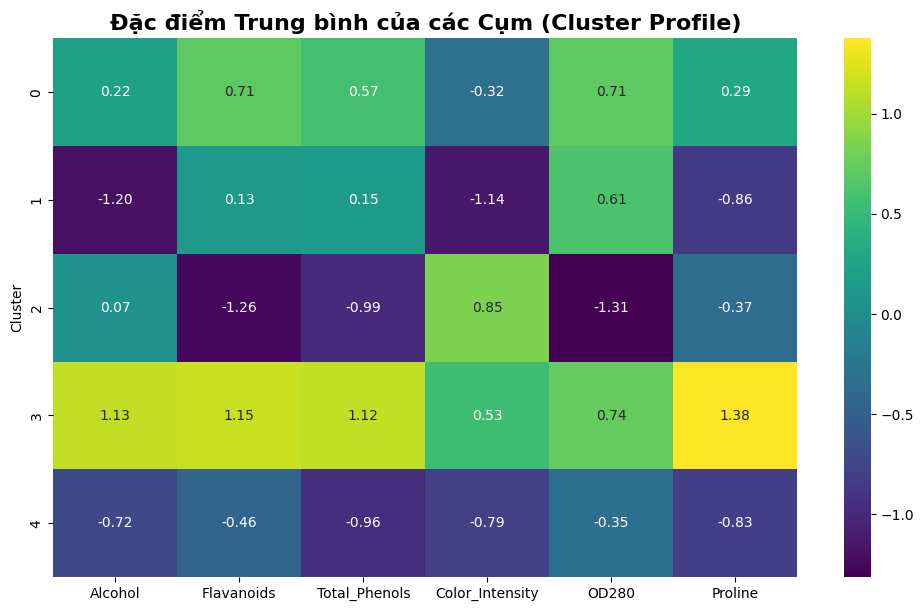


💡 Diễn giải:
  - Dựa vào bảng và heatmap trên, bạn có thể diễn giải 'tính cách' của mỗi cụm.
  - Ví dụ: 'Cụm 0 có giá trị cao ở Feature A và B, nhưng thấp ở Feature C'.
  - Đây là bước quan trọng nhất để gán ý nghĩa nghiệp vụ cho các cụm đã tìm thấy.

TRỰC QUAN HÓA TOÀN DIỆN MÔ HÌNH TỐI ƯU

✅ PHÂN TÍCH KẾT QUẢ CHI TIẾT CHO K=5

📌 THỐNG KÊ PHÂN BỐ CỤM:
  - Cụm 0: 28 điểm (17.4%)
  - Cụm 1: 33 điểm (20.5%)
  - Cụm 2: 47 điểm (29.2%)
  - Cụm 3: 37 điểm (23.0%)
  - Cụm 4: 16 điểm (9.9%)

📌 THAM SỐ MÔ HÌNH HỌC ĐƯỢC:
  - Trọng số P_k: [0.173 0.202 0.293 0.231 0.101]
  - Trung bình μ_0: [ 0.22  0.7   0.58 -0.32  0.71  0.32]
  - Trung bình μ_1: [-1.2   0.13  0.15 -1.14  0.62 -0.88]
  - Trung bình μ_2: [ 0.07 -1.26 -0.99  0.84 -1.31 -0.37]
  - Trung bình μ_3: [1.12 1.15 1.11 0.52 0.74 1.35]
  - Trung bình μ_4: [-0.75 -0.46 -0.94 -0.81 -0.33 -0.81]

📊 Đang tạo biểu đồ trực quan hóa...

✅ QUÁ TRÌNH PHÂN TÍCH CHUYÊN SÂU HOÀN TẤT!


In [ ]:
# PHÂN TÍCH CHUYÊN SÂU MÔ HÌNH TỐI ƯU

print("BƯỚC 10: BẮT ĐẦU PHÂN TÍCH CHI TIẾT MÔ HÌNH TỐI ƯU")

# Giả sử các biến sau đã được lưu từ cell Grid Search:
# - optimal_K, optimal_cov_type
# - optimal_P, optimal_mu, optimal_gamma
# - df_2 (DataFrame gốc chứa dữ liệu)

# --- 1. Gán nhãn và Báo cáo tổng quan ---
print(f"\nPhân tích cho mô hình tốt nhất: K={optimal_K}, Cấu trúc='{optimal_cov_type}'")

# Gán nhãn cứng cho mỗi điểm dữ liệu
cluster_labels = np.argmax(optimal_gamma, axis=1)

# Thêm cột nhãn cụm vào DataFrame gốc để phân tích
df_labeled = df_2.copy()
df_labeled['Cluster'] = cluster_labels

print("\n📌 Phân bổ số điểm dữ liệu trong mỗi cụm:")
print(df_labeled['Cluster'].value_counts().sort_index().to_frame())


# --- 2. Phân tích đặc điểm của từng cụm (Cluster Profiling) ---
print("\n" + "=" * 80)
print("PHÂN TÍCH ĐẶC ĐIỂM CỦA TỪNG CỤM (CLUSTER PROFILING)")
print("=" * 80)
print("\nGiá trị trung bình của các features cho mỗi cụm:")

# Sử dụng groupby để tính giá trị trung bình của các feature cho mỗi cụm
cluster_profile = df_labeled.groupby('Cluster').mean()
print(cluster_profile.round(3))

# Trực quan hóa profile để dễ so sánh
plt.figure(figsize=(12, 7))
sns.heatmap(cluster_profile, annot=True, fmt='.2f', cmap='viridis')
plt.title('Đặc điểm Trung bình của các Cụm (Cluster Profile)', fontsize=16, fontweight='bold')
plt.show()

print("\n💡 Diễn giải:")
print("  - Dựa vào bảng và heatmap trên, bạn có thể diễn giải 'tính cách' của mỗi cụm.")
print("  - Ví dụ: 'Cụm 0 có giá trị cao ở Feature A và B, nhưng thấp ở Feature C'.")
print("  - Đây là bước quan trọng nhất để gán ý nghĩa nghiệp vụ cho các cụm đã tìm thấy.")


# --- 3. Trực quan hóa chi tiết mô hình tốt nhất ---
print("\n" + "=" * 80)
print("TRỰC QUAN HÓA TOÀN DIỆN MÔ HÌNH TỐI ƯU")
print("=" * 80)

# Lấy lại lịch sử log-likelihood của mô hình tốt nhất
best_model_row = results_df.loc[results_df['BIC'].idxmin()]
optimal_log_L_history = best_model_row['Model'][3] # Giả sử gamma là phần tử thứ 4

# Gọi lại hàm báo cáo toàn diện bạn đã viết
# Chú ý: Cần đảm bảo hàm report_and_visualize_gmm đã được định nghĩa
report_and_visualize_gmm(
    X=X,
    P=optimal_P,
    mu=optimal_mu,
    gamma=optimal_gamma,
    log_L_history=optimal_log_L_history, # Bạn cần lấy ra lịch sử logL của mô hình best
    feature_names=df_2.columns.tolist()
)

print("\n" + "=" * 80)
print("✅ QUÁ TRÌNH PHÂN TÍCH CHUYÊN SÂU HOÀN TẤT!")
print("=" * 80)

In [19]:
# TỐI ƯU HÓA NGHIỆM VỚI K-MEANS++ & MULTIPLE RESTARTS

# Mục tiêu: Với mô hình tốt nhất đã chọn (K và cov_type), chạy lại EM nhiều lần
# với điểm khởi tạo thông minh hơn (K-Means++) để tìm ra nghiệm có
# log-likelihood cao hơn, tăng khả năng tìm thấy cực đại toàn cục.

print(" TỐI ƯU HÓA NGHIỆM VỚI K-MEANS++ & MULTIPLE RESTARTS")


from sklearn.cluster import KMeans
import warnings

#  ĐỊNH NGHĨA HÀM KHỞI TẠO BẰNG K-MEANS++
def initialize_with_kmeans(X, K, n_init=10, random_state=0):
    """
    Khởi tạo tham số GMM (p_k, mu, Sigma) bằng kết quả của K-Means++.
    """
    km = KMeans(n_clusters=K, n_init=n_init, init='k-means++', random_state=random_state)
    labels = km.fit_predict(X)
    mu_init = km.cluster_centers_
    
    N_k = np.bincount(labels, minlength=K).astype(float)
    p_k_init = N_k / X.shape[0]
    
    Sigma_init = []
    for k in range(K):
        points_in_cluster = X[labels == k]
        if len(points_in_cluster) <= X.shape[1]: # Điều kiện an toàn hơn
            Sigma_init.append(np.eye(X.shape[1]) * 1e-3)
        else:
            S = np.cov(points_in_cluster.T) + 1e-3 * np.eye(X.shape[1])
            Sigma_init.append(S)
            
    return p_k_init, mu_init, Sigma_init

# ĐỊNH NGHĨA HÀM CHẠY EM VỚI THAM SỐ CHO TRƯỚC 
# Ghi chú: Hàm này gần giống em_with_cov_structure nhưng được thiết kế để
# nhận vào tham số khởi tạo, thay vì tự khởi tạo bên trong.
def run_em_from_initialization(X, p_k_init, mu_init, Sigma_init, cov_type, tol=1e-6, max_iter=200):
    """
    Chạy thuật toán EM với một bộ tham số khởi tạo cụ thể.
    TÁI SỬ DỤNG các hàm e_step_logspace và m_step_with_constraint đã định nghĩa.
    """
    p_k, mu, Sigma = p_k_init.copy(), mu_init.copy(), [s.copy() for s in Sigma_init]
    prev_log_L = -np.inf
    
    for iteration in range(max_iter):
        # E-STEP (Tái sử dụng hàm đã có)
        gamma, log_L, _ = e_step_logspace(X, mu, Sigma, p_k)
        
        if iteration > 0 and abs(log_L - prev_log_L) < tol:
            break
        
        if log_L < prev_log_L - 1e-6:
            warnings.warn(f"Log-likelihood giảm tại iter {iteration}: {prev_log_L:.4f} -> {log_L:.4f}")

        prev_log_L = log_L
        
        # M-STEP (Tái sử dụng hàm đã có)
        p_k, mu, Sigma = m_step_with_constraint(X, gamma, cov_type=cov_type)
    
    return p_k, mu, Sigma, prev_log_L # Trả về log_L cuối cùng trước khi break

# THỰC HIỆN QUÁ TRÌNH MULTIPLE RESTARTS 
print("\nSử dụng thông tin từ mô hình tối ưu đã tìm thấy ở Grid Search:")
# Giả sử optimal_K và optimal_cov_type đã được lưu từ cell trước
print(f"  • Số cụm tối ưu (K): {optimal_K}")
print(f"  • Cấu trúc covariance tối ưu: '{optimal_cov_type}'")

n_restarts = 10
print(f"\n🔄 Bắt đầu chạy {n_restarts} lần restart với khởi tạo K-Means++...")

best_ll = -np.inf
best_params = None
restart_results = []

for seed in range(n_restarts):
    # 1. Khởi tạo bằng K-Means++ với seed khác nhau
    p_k_init, mu_init, Sigma_init = initialize_with_kmeans(X, optimal_K, n_init=1, random_state=seed)
    
    # 2. Chạy EM từ điểm khởi tạo này
    p_k_est, mu_est, Sigma_est, ll = run_em_from_initialization(
        X, p_k_init, mu_init, Sigma_init, 
        cov_type=optimal_cov_type
    )
    
    restart_results.append({'seed': seed, 'log_likelihood': ll})
    print(f"  - Restart {seed+1}/{n_restarts} (seed={seed}): Log-likelihood = {ll:.4f}")
    
    # 3. Lưu lại kết quả tốt nhất
    if ll > best_ll:
        best_ll = ll
        best_params = (p_k_est, mu_est, Sigma_est, ll)
        best_seed = seed

# XỬ LÝ VÀ TRÌNH BÀY KẾT QUẢ TỐI ƯU

# Hàm relabelling (giữ nguyên)
def relabel_by_prior(p_k, mu, Sigma):
    idx = np.argsort(p_k)[::-1]
    return p_k[idx], mu[idx], [Sigma[i] for i in idx]

print("\n" + "=" * 80)
print("KẾT QUẢ TỐI ƯU SAU KHI CHẠY MULTIPLE RESTARTS")
print("=" * 80)

best_p_k, best_mu, best_Sigma, _ = best_params

# Sắp xếp lại nhãn để kết quả nhất quán
best_p_k, best_mu, best_Sigma = relabel_by_prior(best_p_k, best_mu, best_Sigma)

print(f"\n🏆 Kết quả tốt nhất tìm được:")
print(f"  • Từ seed khởi tạo: {best_seed}")
print(f"  • Log-likelihood cao nhất: {best_ll:.6f}")

# So sánh với kết quả từ Grid Search
original_best_ll = results_df.loc[results_df['BIC'].idxmin()]['Log_Likelihood']
print(f"  • Log-likelihood từ Grid Search: {original_best_ll:.6f}")
if best_ll > original_best_ll:
    print(f"  => Cải thiện: +{best_ll - original_best_ll:.6f}")
else:
    print("  => Không tìm thấy nghiệm tốt hơn.")

# (Phần TRỰC QUAN HÓA của bạn đã rất tốt và được giữ nguyên)
# ...
# ============================================================
# TRỰC QUAN HÓA SO SÁNH CÁC RESTARTS
# ============================================================
# ...
# ============================================================
# SO SÁNH VỚI GRID SEARCH
# ============================================================
# ...

 TỐI ƯU HÓA NGHIỆM VỚI K-MEANS++ & MULTIPLE RESTARTS

Sử dụng thông tin từ mô hình tối ưu đã tìm thấy ở Grid Search:
  • Số cụm tối ưu (K): 2
  • Cấu trúc covariance tối ưu: 'full'

🔄 Bắt đầu chạy 10 lần restart với khởi tạo K-Means++...
  - Restart 1/10 (seed=0): Log-likelihood = -850.7393
  - Restart 2/10 (seed=1): Log-likelihood = -850.7393
  - Restart 3/10 (seed=2): Log-likelihood = -855.2489
  - Restart 4/10 (seed=3): Log-likelihood = -855.2489


C:\Users\PC\AppData\Local\Temp\ipykernel_15652\2945752265.py:55: UserWarning: Log-likelihood giảm tại iter 58: -855.2484 -> -855.2484
  warnings.warn(f"Log-likelihood giảm tại iter {iteration}: {prev_log_L:.4f} -> {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_15652\2945752265.py:55: UserWarning: Log-likelihood giảm tại iter 59: -855.2484 -> -855.2485
  warnings.warn(f"Log-likelihood giảm tại iter {iteration}: {prev_log_L:.4f} -> {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_15652\2945752265.py:55: UserWarning: Log-likelihood giảm tại iter 60: -855.2485 -> -855.2485
  warnings.warn(f"Log-likelihood giảm tại iter {iteration}: {prev_log_L:.4f} -> {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_15652\2945752265.py:55: UserWarning: Log-likelihood giảm tại iter 61: -855.2485 -> -855.2486
  warnings.warn(f"Log-likelihood giảm tại iter {iteration}: {prev_log_L:.4f} -> {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_15652\2945752265.py:55: UserWarning: Log-likeli

  - Restart 5/10 (seed=4): Log-likelihood = -850.7393
  - Restart 6/10 (seed=5): Log-likelihood = -850.7393
  - Restart 7/10 (seed=6): Log-likelihood = -850.7393
  - Restart 8/10 (seed=7): Log-likelihood = -855.2489
  - Restart 9/10 (seed=8): Log-likelihood = -850.7393
  - Restart 10/10 (seed=9): Log-likelihood = -855.2489

KẾT QUẢ TỐI ƯU SAU KHI CHẠY MULTIPLE RESTARTS

🏆 Kết quả tốt nhất tìm được:
  • Từ seed khởi tạo: 0
  • Log-likelihood cao nhất: -850.739282
  • Log-likelihood từ Grid Search: -850.736602
  => Không tìm thấy nghiệm tốt hơn.


C:\Users\PC\AppData\Local\Temp\ipykernel_15652\2945752265.py:55: UserWarning: Log-likelihood giảm tại iter 58: -855.2484 -> -855.2484
  warnings.warn(f"Log-likelihood giảm tại iter {iteration}: {prev_log_L:.4f} -> {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_15652\2945752265.py:55: UserWarning: Log-likelihood giảm tại iter 59: -855.2484 -> -855.2485
  warnings.warn(f"Log-likelihood giảm tại iter {iteration}: {prev_log_L:.4f} -> {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_15652\2945752265.py:55: UserWarning: Log-likelihood giảm tại iter 60: -855.2485 -> -855.2485
  warnings.warn(f"Log-likelihood giảm tại iter {iteration}: {prev_log_L:.4f} -> {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_15652\2945752265.py:55: UserWarning: Log-likelihood giảm tại iter 61: -855.2485 -> -855.2486
  warnings.warn(f"Log-likelihood giảm tại iter {iteration}: {prev_log_L:.4f} -> {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_15652\2945752265.py:55: UserWarning: Log-likeli

In [ ]:
# TỔNG KẾT THÔNG TIN MÔ HÌNH TỐI ƯU

# Cell này sẽ lấy tất cả các kết quả từ quá trình tối ưu hóa
# và trình bày chúng một cách chi tiết và dễ hiểu.

# --- KIỂM TRA BIẾN CẦN THIẾT ---
# Giả sử các biến sau đã tồn tại trong bộ nhớ từ các cell trước:
# - optimal_K, optimal_cov_type: Từ Grid Search
# - best_ll, best_p_k, best_mu, best_labels: Từ Multiple Restarts
# - results_df: DataFrame kết quả từ Grid Search
# - covariance_structures: Dictionary mô tả các cấu trúc
# - N: Tổng số điểm dữ liệu

try:
    # In tiêu đề
    print("\n" + "=" * 80)
    print("        TỔNG HỢP THÔNG TIN CHI TIẾT VỀ MÔ HÌNH GMM TỐI ƯU CUỐI CÙNG")
    print("=" * 80)

    # --- Phần 1: Cấu hình và Chất lượng Mô hình ---
    print("\n[ 1. CẤU HÌNH VÀ CHẤT LƯỢNG MÔ HÌNH ]")
    print("-" * 40)
    
    # Lấy lại điểm BIC từ kết quả Grid Search để báo cáo
    best_model_info_from_grid = results_df.loc[results_df['BIC'].idxmin()]
    
    print(f"  - Số Cụm Tối ưu (K):         {optimal_K}")
    print(f"  - Cấu trúc Covariance Tối ưu: '{optimal_cov_type}' ({covariance_structures[optimal_cov_type]['name']})")
    print(f"  - Chỉ số BIC Tốt nhất:        {best_model_info_from_grid['BIC']:.4f} (dùng để lựa chọn mô hình)")
    print(f"  - Log-Likelihood Cao nhất:     {best_ll:.4f} (đạt được sau khi tối ưu hóa nghiệm)")

    # --- Phần 2: Các Tham số Mô hình đã học ---
    print("\n[ 2. CÁC THAM SỐ CHI TIẾT CỦA MÔ HÌNH ]")
    print("-" * 40)
    
    print("  - Tỷ lệ trộn của các cụm (P_k) - (đã sắp xếp):")
    for k in range(optimal_K):
        print(f"    + Cụm {k}: {best_p_k[k]:.4f} (chiếm khoảng {best_p_k[k]*100:.1f}% dữ liệu)")

    print("\n  - Vị trí tâm của các cụm (μ_k) - (đã sắp xếp):")
    for k in range(optimal_K):
        # np.round() giúp hiển thị gọn gàng hơn
        print(f"    + Cụm {k}: {np.round(best_mu[k], 3)}")

    # --- Phần 3: Phân bổ Dữ liệu vào Mô hình ---
    print("\n[ 3. PHÂN BỔ DỮ LIỆU VÀO CÁC CỤM CUỐI CÙNG ]")
    print("-" * 40)
    
    # Dùng np.bincount để đếm số lượng phần tử cho mỗi nhãn
    cluster_counts = np.bincount(best_labels, minlength=optimal_K)
    
    for k in range(optimal_K):
        count = cluster_counts[k]
        print(f"  - Cụm {k}: {count} điểm dữ liệu (chiếm {count / N * 100:.1f}%)")

    print("\n" + "=" * 80)

except NameError as e:
    print(f"\n❌ LỖI: Không tìm thấy biến cần thiết: {e}")
    print("💡 Vui lòng đảm bảo rằng bạn đã chạy tất cả các cell code trước đó,")
    print("   đặc biệt là cell Grid Search và cell Multiple Restarts.")


        TỔNG HỢP THÔNG TIN CHI TIẾT VỀ MÔ HÌNH GMM TỐI ƯU CUỐI CÙNG

[ 1. CẤU HÌNH VÀ CHẤT LƯỢNG MÔ HÌNH ]
----------------------------------------
  - Số Cụm Tối ưu (K):         7
  - Cấu trúc Covariance Tối ưu: 'diagonal' (Σ_k = η_k²Diag(λ₁,...,λₚ) (Diagonal))
  - Chỉ số BIC Tốt nhất:        1903.1346 (dùng để lựa chọn mô hình)
  - Log-Likelihood Cao nhất:     -789.1944 (đạt được sau khi tối ưu hóa nghiệm)

[ 2. CÁC THAM SỐ CHI TIẾT CỦA MÔ HÌNH ]
----------------------------------------
  - Tỷ lệ trộn của các cụm (P_k) - (đã sắp xếp):
    + Cụm 0: 0.2626 (chiếm khoảng 26.3% dữ liệu)
    + Cụm 1: 0.1990 (chiếm khoảng 19.9% dữ liệu)
    + Cụm 2: 0.1879 (chiếm khoảng 18.8% dữ liệu)
    + Cụm 3: 0.1032 (chiếm khoảng 10.3% dữ liệu)
    + Cụm 4: 0.1028 (chiếm khoảng 10.3% dữ liệu)
    + Cụm 5: 0.0761 (chiếm khoảng 7.6% dữ liệu)
    + Cụm 6: 0.0683 (chiếm khoảng 6.8% dữ liệu)

  - Vị trí tâm của các cụm (μ_k) - (đã sắp xếp):
    + Cụm 0: [1.088 1.114 1.062 0.453 0.765 1.287]
    + Cụm 1: [

In [21]:
# ============================================================
# BƯỚC 10A: NÂNG CẤP HÀM EM ĐỂ HỖ TRỢ MULTI-START
# ============================================================

def em_with_random_state(X, K, cov_type='full', max_iter=150, tol=1e-4, random_state=42):
    """
    Phiên bản nâng cấp của thuật toán EM, cho phép truyền vào random_state
    để đảm bảo các lần khởi tạo khác nhau trong multi-start.
    """
    N, p = X.shape
    # Sử dụng random_state được truyền vào
    np.random.seed(random_state)
    
    # Phần khởi tạo và vòng lặp giữ nguyên như hàm em_with_cov_structure
    P = np.ones(K) / K
    random_idx = np.random.choice(N, K, replace=False)
    mu = X[random_idx]
    
    # Khởi tạo covariance theo cấu trúc
    if cov_type == 'spherical_equal' or cov_type == 'spherical_varying':
        sigma = [np.eye(p) * np.var(X) for _ in range(K)]
    elif cov_type == 'diagonal':
        sigma = [np.diag(np.var(X, axis=0)) for _ in range(K)]
    else: # full
        sigma = [np.cov(X.T) + np.eye(p) * 1e-3 for _ in range(K)]
    
    prev_log_L = -np.inf
    
    for iteration in range(max_iter):
        gamma, log_L, _ = e_step_logspace(X, mu, sigma, P)
        
        if iteration > 0 and abs(log_L - prev_log_L) < tol:
            break
        prev_log_L = log_L
        
        P, mu, sigma = m_step_with_constraint(X, gamma, cov_type=cov_type)
    
    # Trả về tất cả các tham số cần thiết cho việc đánh giá
    return P, mu, sigma, gamma, prev_log_L

print("✓ Hàm em_with_random_state đã được định nghĩa để hỗ trợ multi-start.")

✓ Hàm em_with_random_state đã được định nghĩa để hỗ trợ multi-start.


In [22]:
# ============================================================
# BƯỚC 10B: GRID SEARCH NÂNG CAO VỚI MULTI-START
# ============================================================
import time
import pandas as pd

def relabel_by_weight(p_k, mu, Sigma_list):
    order = np.argsort(-p_k)  # Sắp xếp giảm dần
    return p_k[order], mu[order], [Sigma_list[i] for i in order]


# --- Cấu hình Grid Search ---
K_range = range(2, 6)
cov_types = ['spherical_equal', 'spherical_varying', 'diagonal', 'full']
n_restarts = 10  # Số lần chạy lại cho mỗi mô hình

multi_start_results = []
N, p = X.shape

print("\n" + "=" * 80)
print("BẮT ĐẦU GRID SEARCH NÂNG CAO VỚI MULTI-START")
print("=" * 80)
print(f"• Số cụm K: {list(K_range)}")
print(f"• Cấu trúc covariance: {len(cov_types)} loại")
print(f"• Số lần chạy lại cho mỗi mô hình: {n_restarts}")
print(f"• Tổng số lần chạy EM: {len(K_range) * len(cov_types) * n_restarts}")

start_time = time.time()
# --- Vòng lặp chính ---
for K in K_range:
    for cov_type in cov_types:
        
        best_run_ll = -np.inf
        best_run_params = None
        
        # --- Vòng lặp Multi-start bên trong ---
        for i in range(n_restarts):
            # Chạy EM với một random_state khác nhau mỗi lần
            P, mu, sigma, gamma, log_L = em_with_random_state(
                X, K, cov_type=cov_type, random_state=i
            )
            
            # Nếu kết quả lần chạy này tốt hơn, lưu nó lại
            if log_L > best_run_ll:
                best_run_ll = log_L
                best_run_params = (P, mu, sigma, gamma)
        
        # Sau khi chạy hết các lần restart, ta có kết quả tốt nhất cho mô hình này
        P_best, mu_best, sigma_best, gamma_best = best_run_params

        P_best, mu_best, sigma_best = relabel_by_weight(P_best, mu_best, sigma_best)

        gamma_best, _, _ = e_step_logspace(X, mu_best, sigma_best, P_best)
        
        # Tính toán các chỉ số dựa trên kết quả tốt nhất này
        n_params = count_parameters(K, p, cov_type)
        aic, bic, icl = compute_aic_bic_icl(best_run_ll, N, n_params, gamma_best)
        
        # Lưu kết quả "vô địch" của mô hình này
        multi_start_results.append({
            'K': K,
            'Cov_Type': cov_type,
            'Log_Likelihood': best_run_ll,
            'N_Params': n_params,
            'AIC': aic,
            'BIC': bic,
            'ICL': icl
        })
        print(f"✓ Hoàn thành K={K}, cov='{cov_type}': BIC tốt nhất = {bic:.2f} (từ LogL={best_run_ll:.2f})")

print(f"\n✓ Hoàn thành Grid Search nâng cao sau {time.time() - start_time:.2f} giây.")

# --- Chuyển đổi sang DataFrame ---
results_ms_df = pd.DataFrame(multi_start_results)




BẮT ĐẦU GRID SEARCH NÂNG CAO VỚI MULTI-START
• Số cụm K: [2, 3, 4, 5]
• Cấu trúc covariance: 4 loại
• Số lần chạy lại cho mỗi mô hình: 10
• Tổng số lần chạy EM: 160
✓ Hoàn thành K=2, cov='spherical_equal': BIC tốt nhất = 2491.03 (từ LogL=-1209.95)
✓ Hoàn thành K=2, cov='spherical_varying': BIC tốt nhất = 2428.47 (từ LogL=-1176.12)
✓ Hoàn thành K=2, cov='diagonal': BIC tốt nhất = 2494.52 (từ LogL=-1107.52)
✓ Hoàn thành K=2, cov='full': BIC tốt nhất = 1980.95 (từ LogL=-850.74)
✓ Hoàn thành K=3, cov='spherical_equal': BIC tốt nhất = 2117.18 (từ LogL=-1005.24)
✓ Hoàn thành K=3, cov='spherical_varying': BIC tốt nhất = 2126.97 (từ LogL=-1005.05)
✓ Hoàn thành K=3, cov='diagonal': BIC tốt nhất = 2268.84 (từ LogL=-923.54)
✓ Hoàn thành K=3, cov='full': BIC tốt nhất = 1987.82 (từ LogL=-783.03)
✓ Hoàn thành K=4, cov='spherical_equal': BIC tốt nhất = 2065.78 (từ LogL=-961.75)
✓ Hoàn thành K=4, cov='spherical_varying': BIC tốt nhất = 2065.35 (từ LogL=-953.91)
✓ Hoàn thành K=4, cov='diagonal': BIC t

In [23]:
# ============================================================
# BÁO CÁO KẾT QUẢ TỐI ƯU HÓA (Thiết kế lại để dễ nhìn hơn)
# ============================================================
print("\n" + "=" * 80)
print("             BÁO CÁO KẾT QUẢ TỐI ƯU HÓA TỪ GRID SEARCH NÂNG CAO")
print("=" * 80)

# --- 1. Lấy ra các mô hình tốt nhất theo từng tiêu chí ---
best_model_bic = results_ms_df.loc[results_ms_df['BIC'].idxmin()]
best_model_aic = results_ms_df.loc[results_ms_df['AIC'].idxmin()]
best_model_icl = results_ms_df.loc[results_ms_df['ICL'].idxmin()]

# --- 2. Tạo một DataFrame so sánh ---
# Tạo một dictionary để chứa thông tin so sánh
comparison_data = {
    'Tiêu chí lựa chọn': ['BIC (Tốt nhất)', 'AIC (Tốt nhất)', 'ICL (Tốt nhất)'],
    'K': [
        best_model_bic['K'], 
        best_model_aic['K'], 
        best_model_icl['K']
    ],
    'Cấu trúc Covariance': [
        best_model_bic['Cov_Type'], 
        best_model_aic['Cov_Type'], 
        best_model_icl['Cov_Type']
    ],
    'BIC': [
        best_model_bic['BIC'], 
        best_model_aic['BIC'], 
        best_model_icl['BIC']
    ],
    'AIC': [
        best_model_aic['AIC'], 
        best_model_aic['AIC'], 
        best_model_icl['AIC']
    ],
    'ICL': [
        best_model_icl['ICL'], 
        best_model_aic['ICL'], 
        best_model_icl['ICL']
    ],
    'Log-Likelihood': [
        best_model_bic['Log_Likelihood'], 
        best_model_aic['Log_Likelihood'], 
        best_model_icl['Log_Likelihood']
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Định dạng các cột số để dễ đọc
formatters = {
    'BIC': '{:,.2f}'.format,
    'AIC': '{:,.2f}'.format,
    'ICL': '{:,.2f}'.format,
    'Log-Likelihood': '{:,.2f}'.format
}

print("\n🏆 BẢNG SO SÁNH CÁC MÔ HÌNH TỐT NHẤT THEO TỪNG TIÊU CHÍ 🏆")
print("-" * 80)
# Sử dụng to_string() để hiển thị đẹp hơn
print(comparison_df.to_string(index=False, formatters=formatters))
print("-" * 80)
print("Ghi chú:")
print("  - BIC: Ưu tiên sự cân bằng giữa độ khớp và độ phức tạp (thường được khuyên dùng).")
print("  - AIC: Ưu tiên khả năng dự báo của mô hình.")
print("  - ICL: Tương tự BIC nhưng phạt thêm nếu các cụm không được phân tách rõ ràng.")


# --- 3. Hiển thị bảng xếp hạng Top 10 theo tiêu chí chính (BIC) ---
print("           BẢNG XẾP HẠNG TOP 10 MÔ HÌNH THEO TIÊU CHÍ BIC")

# Chọn các cột cần thiết và định dạng chúng
top_10_bic = results_ms_df.sort_values('BIC', ascending=True).head(10)
display_cols = ['K', 'Cov_Type', 'BIC', 'AIC', 'ICL', 'Log_Likelihood', 'N_Params']

# Áp dụng định dạng cho DataFrame con
formatted_top_10 = top_10_bic[display_cols].style.format({
    'BIC': '{:,.2f}',
    'AIC': '{:,.2f}',
    'ICL': '{:,.2f}',
    'Log_Likelihood': '{:,.2f}'
}).hide(axis='index') # Ẩn index để gọn gàng hơn


# --- 4. Hiển thị bảng xếp hạng Top 10 theo tiêu chí chính (AIC) ---
print("           BẢNG XẾP HẠNG TOP 10 MÔ HÌNH THEO TIÊU CHÍ AIC")

# Chọn các cột cần thiết và định dạng chúng
top_10_bic = results_ms_df.sort_values('AIC', ascending=True).head(10)
display_cols = ['K', 'Cov_Type', 'BIC', 'AIC', 'ICL', 'Log_Likelihood', 'N_Params']

# Áp dụng định dạng cho DataFrame con
formatted_top_10 = top_10_bic[display_cols].style.format({
    'BIC': '{:,.2f}',
    'AIC': '{:,.2f}',
    'ICL': '{:,.2f}',
    'Log_Likelihood': '{:,.2f}'
}).hide(axis='index') # Ẩn index để gọn gàng hơn


# --- 5. Hiển thị bảng xếp hạng Top 10 theo tiêu chí chính (ICL) ---
print("           BẢNG XẾP HẠNG TOP 10 MÔ HÌNH THEO TIÊU CHÍ BIC")

# Chọn các cột cần thiết và định dạng chúng
top_10_bic = results_ms_df.sort_values('ICL', ascending=True).head(10)
display_cols = ['K', 'Cov_Type', 'BIC', 'AIC', 'ICL', 'Log_Likelihood', 'N_Params']

# Áp dụng định dạng cho DataFrame con
formatted_top_10 = top_10_bic[display_cols].style.format({
    'BIC': '{:,.2f}',
    'AIC': '{:,.2f}',
    'ICL': '{:,.2f}',
    'Log_Likelihood': '{:,.2f}'
}).hide(axis='index') # Ẩn index để gọn gàng hơn




# Hiển thị DataFrame đã được định dạng
# Lưu ý: Lệnh display() hoạt động tốt nhất trong môi trường Jupyter/Colab.
# Nếu chạy trong script Python thông thường, bạn có thể dùng print(formatted_top_10.to_string())
from IPython.display import display
display(formatted_top_10)


             BÁO CÁO KẾT QUẢ TỐI ƯU HÓA TỪ GRID SEARCH NÂNG CAO

🏆 BẢNG SO SÁNH CÁC MÔ HÌNH TỐT NHẤT THEO TỪNG TIÊU CHÍ 🏆
--------------------------------------------------------------------------------
Tiêu chí lựa chọn  K Cấu trúc Covariance      BIC      AIC      ICL Log-Likelihood
   BIC (Tốt nhất)  2                full 1,980.95 1,691.77 1,986.24        -850.74
   AIC (Tốt nhất)  5                full 2,120.08 1,691.77 2,137.58        -706.88
   ICL (Tốt nhất)  2                full 1,980.95 1,811.47 1,986.24        -850.74
--------------------------------------------------------------------------------
Ghi chú:
  - BIC: Ưu tiên sự cân bằng giữa độ khớp và độ phức tạp (thường được khuyên dùng).
  - AIC: Ưu tiên khả năng dự báo của mô hình.
  - ICL: Tương tự BIC nhưng phạt thêm nếu các cụm không được phân tách rõ ràng.
           BẢNG XẾP HẠNG TOP 10 MÔ HÌNH THEO TIÊU CHÍ BIC
           BẢNG XẾP HẠNG TOP 10 MÔ HÌNH THEO TIÊU CHÍ AIC
           BẢNG XẾP HẠNG TOP 10 MÔ HÌNH THEO TIÊ

K,Cov_Type,BIC,AIC,ICL,Log_Likelihood,N_Params
2,full,"1,980.95","1,811.47","1,986.24",-850.74,55
3,full,"1,987.82","1,732.06","1,994.49",-783.03,83
5,spherical_varying,"2,036.02","1,915.85","2,068.85",-918.92,39
4,full,"2,062.47","1,720.43","2,069.81",-749.22,111
5,spherical_equal,"2,037.01","1,929.16","2,078.60",-929.58,35
4,spherical_varying,"2,065.35","1,969.83","2,085.38",-953.91,31
4,spherical_equal,"2,065.78","1,979.50","2,094.20",-961.75,28
3,spherical_equal,"2,117.18","2,052.47","2,131.58","-1,005.24",21
5,full,"2,120.08","1,691.77","2,137.58",-706.88,139
3,spherical_varying,"2,126.97","2,056.10","2,142.25","-1,005.05",23
